# P3. Redes neuronales
**Caso Práctico: Fashion-MNIST en Google Colab**

*Aprendizaxe Automática Supervisada*

3º GrIA. Curso 2025/26</center>

**PARTICIPANTES**:
*   Alumno 1: Mateo, Fraguas Abal
*   Alumno 2: Álvaro, Garnelo Luaces
*   Alumno 3: Karol, Badura


# 0. Configuración del entorno



In [41]:
# Required imports
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt           # For plotting images
import time                               # For measuring execution time

# Configure Jupyter to display all outputs in a cell / not necessary
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

# TensorFlow / Keras imports for building neural network models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
# Semilla e inicialización con numpy

SEMILLA = 1492
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

# 1. Carga del dataset

In [25]:
#CARGAMOS LOS DATASETS
dt_train = pd.read_csv('fashion-mnist_train.csv', sep=',')
dt_test = pd.read_csv('fashion-mnist_test.csv', sep=',')

In [26]:
#SEPARACION EN ETIQUETAS Y CARACTERISTICAS
X_train = dt_train.drop(columns=['label'],axis=1)
y_train = dt_train[['label']]

X_test = dt_test.drop(columns=['label'],axis=1)
y_test = dt_test[['label']]

In [27]:
#GESTION DE VALORES FALTANTES
imputer = SimpleImputer(strategy='mean')

train_imputed = imputer.fit_transform(X_train)
X_train = pd.DataFrame(train_imputed, columns=X_train.columns)

test_imputed = imputer.fit_transform(X_test)
X_test = pd.DataFrame(test_imputed, columns=X_test.columns)

# 2. Inspección y visualización de los datos

In [7]:
dt_train.head()
dt_train.shape

dt_test.head()
dt_test.shape

(10000, 785)

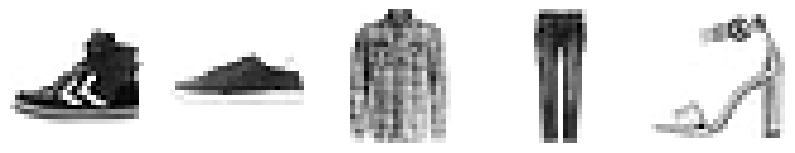

In [8]:
# Showing 5 random, different images

indices = np.random.choice(len(y_train), 5, replace=False)

plt.figure(figsize=(10, 2))
for i, idx in enumerate(indices):
    img = X_train.iloc[idx].values.reshape(28, 28)
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray_r')
    plt.axis('off')

plt.show()



# 3. Entrenamiento de un perceptrón multicapa


In [28]:
# Divide by 255
X_train_255 = X_train / 255.0
X_test_255 = X_test / 255.0

# MinMaxScaler
scaler = MinMaxScaler()
X_train_mms = scaler.fit_transform(X_train)
X_test_mms = scaler.fit_transform(X_test)

## 3.1. MLPClassifier - scikit-learn

* Entrenad un perceptrón MLP con sklearn para el conjunto de datos escalado previamente
* Utilizad como variables de entrada todos los píxeles sin procesa (784). No es necesario optimizar los hiperparámetros de la red.
* Probar una arquitectura de red no demasiado compleja
* Medir el error en el conjunto de prueba

_NOTA: Es recomendable mostrar el progreso del aprendizaje_

In [12]:
# Train-MLP function

def train_mlp(X_train, y_train, X_test, y_test, description=""):
  print(f"Training sklearn MLP ({description})\n")

  start_time = time.time()

  mlp = MLPClassifier(
    random_state=SEMILLA,
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    max_iter=25,
    verbose=True
  )

  mlp.fit(X_train, y_train)
  y_pred = mlp.predict(X_test)
  acc = accuracy_score(y_test, y_pred)

  # End timing
  elapsed = time.time() - start_time

  print("\n")
  print(f"Test accuracy: {acc:.4f}")
  print(f"Training time: {elapsed:.2f} seconds\n")

  return acc, elapsed

In [13]:
acc_255, time_255 = train_mlp(
    X_train_255, y_train, X_test_255, y_test,
    description="Scaled by dividing by 255"
)

acc_std, time_std = train_mlp(
    X_train_mms, y_train, X_test_mms, y_test,
    description="MinMaxScaler"
)

Training sklearn MLP (Scaled by dividing by 255)



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 1.36511931
Iteration 2, loss = 0.68893048
Iteration 3, loss = 0.57065136
Iteration 4, loss = 0.51928458
Iteration 5, loss = 0.48867211
Iteration 6, loss = 0.45487024
Iteration 7, loss = 0.43587447
Iteration 8, loss = 0.41759488
Iteration 9, loss = 0.39524890
Iteration 10, loss = 0.39073772
Iteration 11, loss = 0.36563113
Iteration 12, loss = 0.35852865
Iteration 13, loss = 0.34306106
Iteration 14, loss = 0.34146538
Iteration 15, loss = 0.32611124
Iteration 16, loss = 0.32003675
Iteration 17, loss = 0.30297115
Iteration 18, loss = 0.29107445
Iteration 19, loss = 0.28626962
Iteration 20, loss = 0.28813610
Iteration 21, loss = 0.27741035
Iteration 22, loss = 0.27271920
Iteration 23, loss = 0.26100754
Iteration 24, loss = 0.24929752
Iteration 25, loss = 0.24919928


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)




Test accuracy: 0.8455
Training time: 7.50 seconds

Training sklearn MLP (MinMaxScaler)

Iteration 1, loss = 1.36400384
Iteration 2, loss = 0.68665084
Iteration 3, loss = 0.57097737
Iteration 4, loss = 0.51879937
Iteration 5, loss = 0.48832720
Iteration 6, loss = 0.45410321
Iteration 7, loss = 0.43818085
Iteration 8, loss = 0.41800732
Iteration 9, loss = 0.39488973
Iteration 10, loss = 0.39347642
Iteration 11, loss = 0.36737335
Iteration 12, loss = 0.36194915
Iteration 13, loss = 0.34681477
Iteration 14, loss = 0.34587375
Iteration 15, loss = 0.32767211
Iteration 16, loss = 0.32261777
Iteration 17, loss = 0.30868212
Iteration 18, loss = 0.29463913
Iteration 19, loss = 0.29162613
Iteration 20, loss = 0.29304854
Iteration 21, loss = 0.28204484
Iteration 22, loss = 0.27515529
Iteration 23, loss = 0.26440163
Iteration 24, loss = 0.25390458
Iteration 25, loss = 0.25432980


Test accuracy: 0.8464
Training time: 5.49 seconds



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


## 3.2. MLP - Keras

Repetid el entrenamiento, pero esta vez usando la API de Keras con el framework TensorFlow

In [ ]:
num_classes = 10

def train_keras(X_train, y_train, X_test, y_test, description=""):
  print(f"Training Keras MLP ({description})\n")

  # All 784
  num_features = X_train.shape[1]

  start_time = time.time()
  


  inputs = keras.Input(shape=(num_features,))
  x = layers.Dense(64, activation="relu")(inputs)
  x = layers.Dense(32, activation="relu")(x)
  outputs = layers.Dense(num_classes, activation="softmax")(x)
  model = keras.Model(inputs, outputs)

  # Compile the model
  model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )

  # Train and display
  history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=512,
    validation_data=(X_test, y_test),
    verbose=2
  )


  test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
  elapsed = time.time() - start_time


  print(f"\nKeras MLP test accuracy: {test_acc:.4f}")
  print(f"Training time: {elapsed:.2f} seconds\n")

  return test_acc, elapsed, history

In [ ]:
acc_keras_255, time_keras_255, hist_keras_255 = train_keras(
    X_train_255, y_train, X_test_255, y_test,
    description="Scaled by dividing by 255"
)



Training Keras MLP (Scaled by dividing by 255)

Epoch 1/25
118/118 - 4s - 33ms/step - accuracy: 0.7188 - loss: 0.8600 - val_accuracy: 0.8147 - val_loss: 0.5483
Epoch 2/25
118/118 - 0s - 4ms/step - accuracy: 0.8366 - loss: 0.4737 - val_accuracy: 0.8457 - val_loss: 0.4398
Epoch 3/25
118/118 - 0s - 4ms/step - accuracy: 0.8524 - loss: 0.4234 - val_accuracy: 0.8581 - val_loss: 0.4174
Epoch 4/25
118/118 - 0s - 3ms/step - accuracy: 0.8616 - loss: 0.3944 - val_accuracy: 0.8594 - val_loss: 0.4071
Epoch 5/25
118/118 - 0s - 4ms/step - accuracy: 0.8689 - loss: 0.3749 - val_accuracy: 0.8619 - val_loss: 0.3927
Epoch 6/25
118/118 - 0s - 3ms/step - accuracy: 0.8726 - loss: 0.3620 - val_accuracy: 0.8721 - val_loss: 0.3734
Epoch 7/25
118/118 - 0s - 4ms/step - accuracy: 0.8772 - loss: 0.3481 - val_accuracy: 0.8746 - val_loss: 0.3616
Epoch 8/25
118/118 - 0s - 4ms/step - accuracy: 0.8808 - loss: 0.3388 - val_accuracy: 0.8748 - val_loss: 0.3519
Epoch 9/25
118/118 - 0s - 4ms/step - accuracy: 0.8846 - loss: 0

## 3.3. Comparación de resultados

Comparad los resultados obtenidos por Keras y Sklearn, en cuanto a rendimiento (precisión y tiempo de ejecución)

Los resultados obtenidos con sklearn y keras aportan accuracies casi idénticas. La principal diferencia entre estas dos librerías es que keras nos permite aprovechar la potencia de cómputo de una gpu, y al optimizar el tamaño del batch, es posible reducir significativamente el tiempo de entrenamiento sin sacrificar apenas precisión.

# 4. Entrenamiento de CNNs

#### Entrenar ahora una CNN con la arquitectura indicada en el enunciado:
* Conv. 2D con 16 filtros y kernel 3x3
* MaxPooling 2x2
* Dense de 20 neuronas
* Optimización con SGD lr=0.1
* 10 epochs
* Batch 128

In [29]:
# Reshape standardized data into 28x28x1 format for CNNs (as said in an email I think)
X_train_cnn = X_train_255.to_numpy().reshape(-1, 28, 28, 1).astype("float32")
X_test_cnn  = X_test_255.to_numpy().reshape(-1, 28, 28, 1).astype("float32")

# Convert labels
y_train_cnn = np.asarray(y_train)
y_test_cnn  = np.asarray(y_test)

print("Training shapes:", X_train_cnn.shape, y_train_cnn.shape)

Training shapes: (60000, 28, 28, 1) (60000, 1)


In [30]:
inputs = keras.Input(shape=(28, 28, 1))

# Conv. 2D con 16 filtros y kernel 3x3
x = layers.Conv2D(16, (3, 3), activation="relu")(inputs)

# MaxPooling 2x2
x = layers.MaxPooling2D((2, 2))(x)

# Flatten tensor for dense layers
x = layers.Flatten()(x)

# Dense de 20 neuronas
x = layers.Dense(20, activation="relu")(x)

outputs = layers.Dense(10, activation="softmax")(x)
model_cnn_basic = keras.Model(inputs, outputs)

# Optimización con SGD lr=0.1
optimizer = keras.optimizers.SGD(learning_rate=0.1)

model_cnn_basic.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [75]:
# 10 epochs
# Batch 128
start_time = time.time()
history_cnn_basic = model_cnn_basic.fit(
    X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=128,
    validation_data=(X_test_cnn, y_test_cnn),
    verbose=2
)
elapsed_basic = time.time() - start_time


Epoch 1/10
469/469 - 2s - 4ms/step - accuracy: 0.9438 - loss: 0.1575 - val_accuracy: 0.9097 - val_loss: 0.2829
Epoch 2/10
469/469 - 1s - 3ms/step - accuracy: 0.9449 - loss: 0.1542 - val_accuracy: 0.9093 - val_loss: 0.2842
Epoch 3/10
469/469 - 1s - 3ms/step - accuracy: 0.9462 - loss: 0.1510 - val_accuracy: 0.9092 - val_loss: 0.2854
Epoch 4/10
469/469 - 1s - 3ms/step - accuracy: 0.9480 - loss: 0.1478 - val_accuracy: 0.9092 - val_loss: 0.2865
Epoch 5/10
469/469 - 1s - 3ms/step - accuracy: 0.9486 - loss: 0.1447 - val_accuracy: 0.9087 - val_loss: 0.2897
Epoch 6/10
469/469 - 1s - 3ms/step - accuracy: 0.9499 - loss: 0.1417 - val_accuracy: 0.9092 - val_loss: 0.2905
Epoch 7/10
469/469 - 1s - 3ms/step - accuracy: 0.9510 - loss: 0.1384 - val_accuracy: 0.9092 - val_loss: 0.2928
Epoch 8/10
469/469 - 2s - 3ms/step - accuracy: 0.9527 - loss: 0.1358 - val_accuracy: 0.9099 - val_loss: 0.2968
Epoch 9/10
469/469 - 2s - 4ms/step - accuracy: 0.9536 - loss: 0.1326 - val_accuracy: 0.9095 - val_loss: 0.3014
E

In [76]:
# Evaluate on test set
test_loss_basic, test_acc_basic = model_cnn_basic.evaluate(X_test_cnn,
                                                           y_test_cnn,
                                                           verbose=0)
print("\nBasic CNN performance:")
print(f"Test accuracy: {test_acc_basic:.4f}")
print(f"Execution time: {elapsed_basic:.2f} seconds")


Basic CNN performance:
Test accuracy: 0.9095
Execution time: 15.26 seconds


#### Intentad mejorar la arquitectura de red anterior, con total libertad en el diseño, pudiendo aumentar la profundidad de la red, introducir otros tipos de capas, usar otros optimizadores, etc.


In [82]:
inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation="relu")(inputs)
x = layers.MaxPooling2D((2, 2))(x)

#LA NUEVA CAPA CONVULACIONAL
x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)

# Dropout(0.25):
# - Randomly drops 25% of the units during training.
# - Helps regularize the model and combat overfitting.
x = layers.Dropout(0.25)(x)

#AUMENTAMOS TAMAÑO DE LA CAPA DENSA
x = layers.Dense(128, activation="relu")(x)

outputs = layers.Dense(10, activation="softmax")(x)

model_cnn_improved = keras.Model(inputs, outputs)

#USAMOS EARLY_STOPPING
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

#USMAOS ADAM
model_cnn_improved.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [83]:
start_time = time.time()
history_cnn_improved = model_cnn_improved.fit(
    X_train_cnn, y_train_cnn,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_cnn, y_test_cnn),
    verbose=2,
    callbacks=[early_stop]
)
elapsed_imp = time.time() - start_time

Epoch 1/100
469/469 - 7s - 15ms/step - accuracy: 0.7943 - loss: 0.5675 - val_accuracy: 0.8627 - val_loss: 0.3899
Epoch 2/100
469/469 - 2s - 5ms/step - accuracy: 0.8648 - loss: 0.3731 - val_accuracy: 0.8830 - val_loss: 0.3334
Epoch 3/100
469/469 - 2s - 4ms/step - accuracy: 0.8823 - loss: 0.3247 - val_accuracy: 0.8932 - val_loss: 0.2947
Epoch 4/100
469/469 - 2s - 4ms/step - accuracy: 0.8925 - loss: 0.2939 - val_accuracy: 0.9016 - val_loss: 0.2668
Epoch 5/100
469/469 - 2s - 4ms/step - accuracy: 0.9000 - loss: 0.2729 - val_accuracy: 0.9072 - val_loss: 0.2582
Epoch 6/100
469/469 - 2s - 4ms/step - accuracy: 0.9069 - loss: 0.2540 - val_accuracy: 0.9111 - val_loss: 0.2464
Epoch 7/100
469/469 - 2s - 4ms/step - accuracy: 0.9135 - loss: 0.2379 - val_accuracy: 0.9150 - val_loss: 0.2371
Epoch 8/100
469/469 - 2s - 5ms/step - accuracy: 0.9163 - loss: 0.2256 - val_accuracy: 0.9166 - val_loss: 0.2279
Epoch 9/100
469/469 - 2s - 4ms/step - accuracy: 0.9204 - loss: 0.2120 - val_accuracy: 0.9182 - val_loss

In [84]:
test_loss_imp, test_acc_imp = model_cnn_improved.evaluate(X_test_cnn, y_test_cnn, verbose=0)

print(f"\nImproved CNN - test accuracy: {test_acc_imp:.4f}")
print(f"Training time: {elapsed_imp:.2f} seconds\n")


Improved CNN - test accuracy: 0.9211
Training time: 38.47 seconds



#### Comparad las distintas arquitecturas de CNN construidas en 2d, en términos de complejidad y rendimiento respecto a los datos de entrenamiento y prueba.

Con estas mejoras, el modelo final logra una accuracy superior en un 2% respecto al modelo base, aumentando apenas 7 segundos el tiempo total de entrenamiento. En términos de complejidad, la red sigue siendo ligera, lo que facilita su entrenamiento en GPU sin requerir recursos excesivos, mientras que el rendimiento en datos de prueba se mantiene alto y estable.